# Analysis of Sector ETF Prices (2018): Financial Networks

In [37]:
'''Construction of dyanamic financial networks from etf price data, and analysis of their properties.'''

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns

import networkx as nx
from scipy.sparse.csgraph import minimum_spanning_tree

In [38]:
# Function to construct the minimum spanning tree graph from the distance matrix
def mst_graph(D: np.ndarray, stock_names: list[str]):
    mst_sparse = minimum_spanning_tree(D)
    mst_coo = mst_sparse.tocoo()

    G = nx.Graph()
    G.add_nodes_from(stock_names)

    for u, v, w in zip(mst_coo.row, mst_coo.col, mst_coo.data):
        G.add_edge(stock_names[u], stock_names[v], weight=float(w), edge_type="mst")

    return G

# Function to construct the threshold graph from the correlation matrix
def threshold_graph(C: np.ndarray, stock_names: list[str], corr_threshold: float):
    G = nx.Graph()
    G.add_nodes_from(stock_names)

    n = C.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            if C[i, j] >= corr_threshold:
                G.add_edge(stock_names[i], stock_names[j], weight=C[i, j], edge_type="threshold")
    return G

# Function to construct the combined graph with both MST and threshold edges
def mst_threshold_graph(C: np.ndarray, D: np.ndarray, stock_names: list[str], corr_threshold: float):
    G = mst_graph(D, stock_names)
    
    n = C.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            if C[i, j] >= corr_threshold and not G.has_edge(stock_names[i], stock_names[j]):
                G.add_edge(stock_names[i], stock_names[j], weight=C[i, j], edge_type="threshold")
    return G

### Exploratory Data Analysis

In [39]:
df_price = pd.read_csv("data/sector_etf_prices.csv")
df_price["Date"] = pd.to_datetime(df_price["Date"], format="%Y-%m-%d")
df_price = df_price.dropna(how="any", axis=0).reset_index(drop=True)
df_price.head()

,Date,XLF,XLC,XLE,XLB,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
0,2018-06-19,23.704649,46.472126,26.737791,25.089108,64.433472,33.221359,41.704494,24.398005,19.823647,74.649956,52.020676
1,2018-06-20,23.643972,47.048851,26.855848,25.007612,64.477463,33.291138,41.745331,24.661348,19.839447,74.808281,52.267326
2,2018-06-21,23.574638,46.760487,26.358582,24.741665,63.667965,33.035316,41.827003,24.808512,19.906597,74.377243,51.895027
3,2018-06-22,23.461969,46.965149,26.884470,25.101980,63.887947,32.928356,42.170048,25.025383,20.044834,74.711517,51.806599
4,2018-06-25,23.210621,45.997738,26.344273,24.711637,63.078468,32.244671,42.382412,24.963415,20.376616,74.025345,50.680374


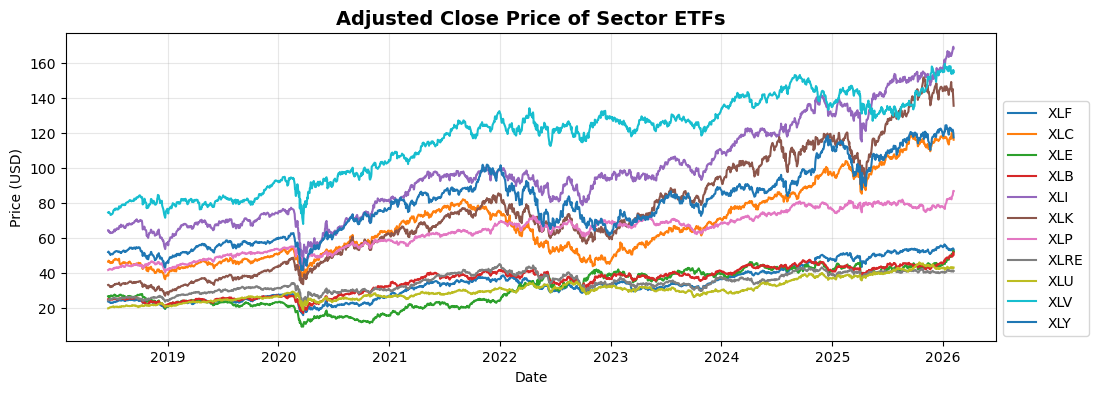

In [40]:
plt.figure(figsize=(12, 4))

for col in df_price.columns[1:]:
    plt.plot(df_price["Date"], df_price[col], label=col)

plt.title("Adjusted Close Price of Sector ETFs", fontsize=14, fontweight="bold")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.legend(loc="upper left", bbox_to_anchor=(1, 0.8))
plt.grid(True, alpha=0.3)
plt.savefig("images/fig1_prices_sectors2018.png", bbox_inches="tight")
plt.show()

In [41]:
df_logreturns = pd.DataFrame()
df_logreturns["Date"] = df_price["Date"]

for col in df_price.columns[1:]:
    df_logreturns[col] = np.log(df_price[col]) - np.log(df_price[col].shift(1))

df_logreturns = df_logreturns.dropna().reset_index(drop=True)
df_logreturns.head()

,Date,XLF,XLC,XLE,XLB,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
0,2018-06-20,-0.002563,0.012334,0.004406,-0.003254,0.000683,0.002098,0.000979,0.010736,0.000797,0.002119,0.004730
1,2018-06-21,-0.002937,-0.006148,-0.018690,-0.010692,-0.012634,-0.007714,0.001955,0.005950,0.003379,-0.005779,-0.007148
2,2018-06-22,-0.004791,0.004367,0.019755,0.014458,0.003449,-0.003243,0.008168,0.008704,0.006920,0.004484,-0.001705
3,2018-06-25,-0.010771,-0.020814,-0.020298,-0.015672,-0.012751,-0.020981,0.005023,-0.002479,0.016416,-0.009227,-0.021979
4,2018-06-26,-0.003367,0.001657,0.012550,0.003812,0.003759,0.004031,-0.004249,0.005261,0.001162,-0.003094,0.007137


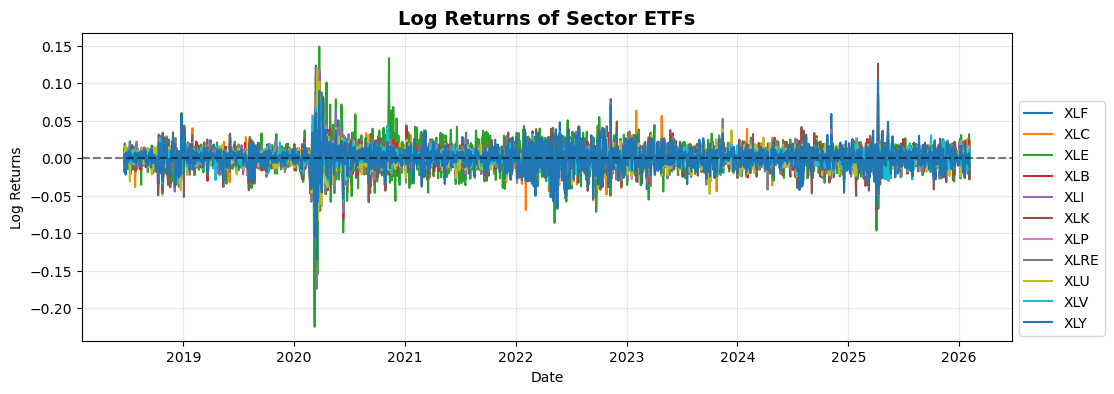

In [42]:
plt.figure(figsize=(12, 4))

for col in df_logreturns.columns[1:]:
    plt.plot(df_logreturns["Date"], df_logreturns[col], label=col)

plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.title("Log Returns of Sector ETFs", fontsize=14, fontweight="bold")
plt.ylabel("Log Returns")
plt.xlabel("Date")
plt.legend(loc="upper left", bbox_to_anchor=(1, 0.8))
plt.grid(True, alpha=0.3)
plt.savefig("images/fig2_logreturns_sectors2018.png", bbox_inches="tight")
plt.show()

In [43]:
df_logreturns.iloc[:, 1:].describe()
for col in df_logreturns.columns[1:]:
    print(f"{col} Skewness: {df_logreturns[col].skew():.4f}")
    print(f"{col} Kurtosis: {df_logreturns[col].kurtosis():.4f}\n")

XLF Skewness: -0.5760
XLF Kurtosis: 15.4655

XLC Skewness: -0.4841
XLC Kurtosis: 7.2064

XLE Skewness: -0.9562
XLE Kurtosis: 15.2273

XLB Skewness: -0.4112
XLB Kurtosis: 9.7065

XLI Skewness: -0.5199
XLI Kurtosis: 13.3286

XLK Skewness: -0.2769
XLK Kurtosis: 8.5076

XLP Skewness: -0.4528
XLP Kurtosis: 15.6112

XLRE Skewness: -1.0485
XLRE Kurtosis: 17.6105

XLU Skewness: -0.2588
XLU Kurtosis: 15.3978

XLV Skewness: -0.4026
XLV Kurtosis: 10.3663

XLY Skewness: -0.5375
XLY Kurtosis: 7.7360



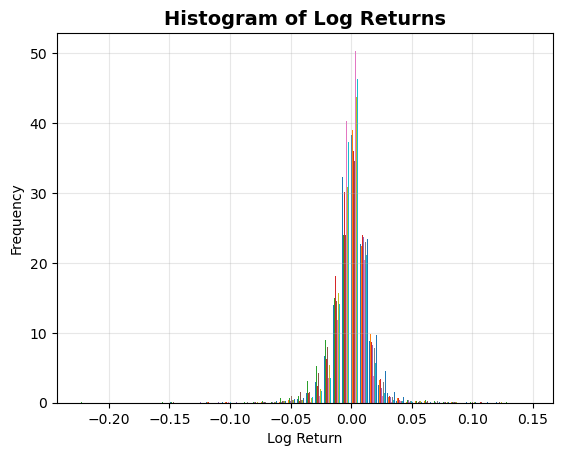

In [44]:
plt.hist(df_logreturns.iloc[:, 1:], bins=50,density=True, label=df_logreturns.columns[1:])
plt.title("Histogram of Log Returns", fontsize=14, fontweight="bold")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

### Global Relationship (2018 - 2026)

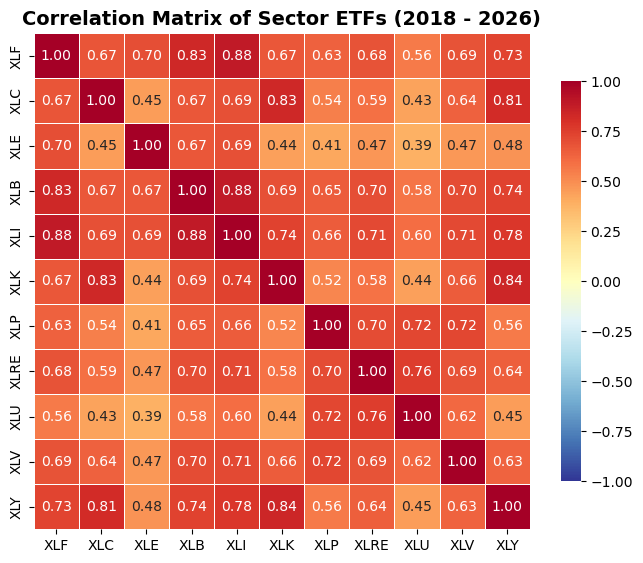

In [45]:
correlation_matrix = df_logreturns.iloc[:, 1:].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="RdYlBu_r", vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax,)
plt.title("Correlation Matrix of Sector ETFs (2018 - 2026)", fontsize=14, fontweight="bold")
plt.savefig("images/fig3_corr_heatmap_sectors2018.png", dpi=200, bbox_inches="tight")
plt.show()

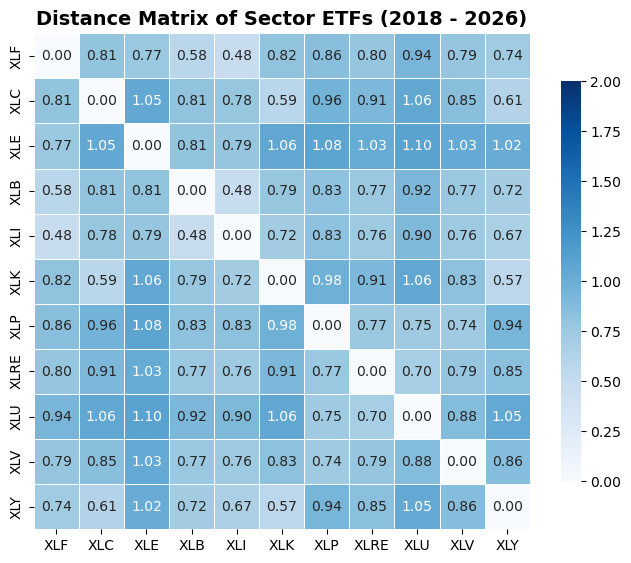

In [46]:
distance_matrix = np.sqrt(2 * (1 - correlation_matrix))

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(distance_matrix, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=2, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax,)
plt.title("Distance Matrix of Sector ETFs (2018 - 2026)", fontsize=14, fontweight="bold")
plt.show()

C:\Users\Abbin\AppData\Local\Temp\ipykernel_33600\3938882723.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", n)


<Figure size 800x650 with 0 Axes>

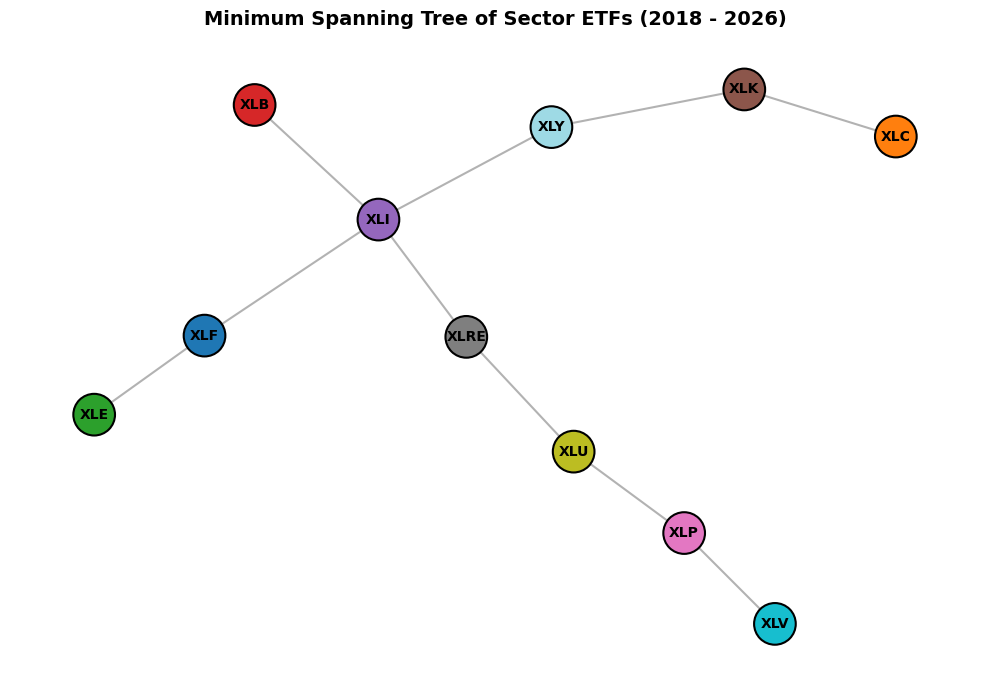

In [47]:
global_mst = mst_graph(distance_matrix.values, df_logreturns.columns[1:].tolist())

plt.figure(figsize=(8, 6.5))
pos = nx.spring_layout(global_mst, seed = 40, k=0.5)

nodes = list(global_mst.nodes())
n = len(nodes)
cmap = plt.cm.get_cmap("tab20", n)
node_colors = [cmap(i) for i in range(n)]

plt.figure(figsize=(10, 7))

nx.draw_networkx_edges(global_mst, pos, edge_color="gray", alpha=0.6, width=1.5)
nx.draw_networkx_nodes(global_mst, pos, node_color=node_colors, node_size=900, edgecolors="black", linewidths=1.5)
nx.draw_networkx_labels(global_mst, pos, font_size=10, font_weight="bold")

plt.title("Minimum Spanning Tree of Sector ETFs (2018 - 2026)", fontsize=14, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.savefig("images/fig4_mst_sectors2018.png", dpi=200, bbox_inches="tight")
plt.show()

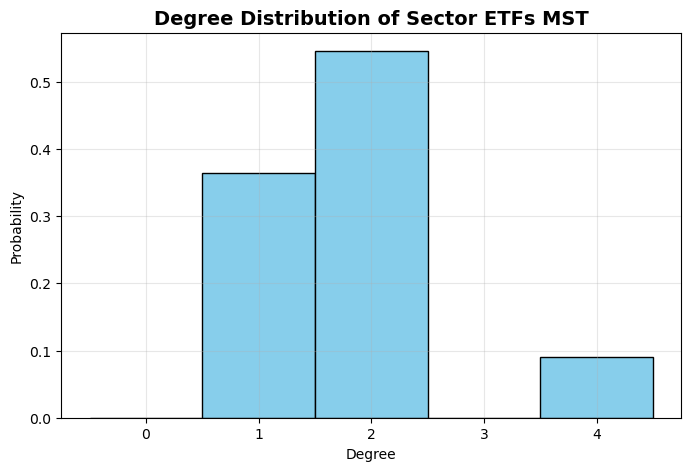

In [48]:
degree_distribution = [degree for node, degree in global_mst.degree()]

plt.figure(figsize=(8, 5))
plt.hist(degree_distribution, bins=np.arange(0, max(degree_distribution) + 2) - 0.5, density=True, color="skyblue", edgecolor="black")
plt.title("Degree Distribution of Sector ETFs MST", fontsize=14, fontweight="bold")
plt.xlabel("Degree")
plt.ylabel("Probability")
plt.grid(True, alpha=0.3)
plt.savefig("images/fig5_degree_dist_mst_sectors2018.png", dpi=200, bbox_inches="tight")
plt.show()

### Local Relationship (epoch_length = 40, epoch_shift = 20)

In [49]:
epoch_length = 40
epoch_shift = 20

stock_names = df_logreturns.columns[1:].tolist()

correlation_matrices = []
distance_matrices = []
mu_values = []
epoch_dates = []

for i in range(0, len(df_logreturns) - epoch_length, epoch_shift):
  epoch = df_logreturns.iloc[i:i+epoch_length]

  correlation_matrix = epoch.iloc[:, 1:].corr().values
  distance_matrix = np.sqrt(2 * (1 - correlation_matrix))
  mu = np.mean(correlation_matrix)

  correlation_matrices.append(correlation_matrix)
  distance_matrices.append(distance_matrix)
  mu_values.append(mu)

  epoch_dates.append(epoch["Date"].iloc[-1])

print(len(correlation_matrices))

94


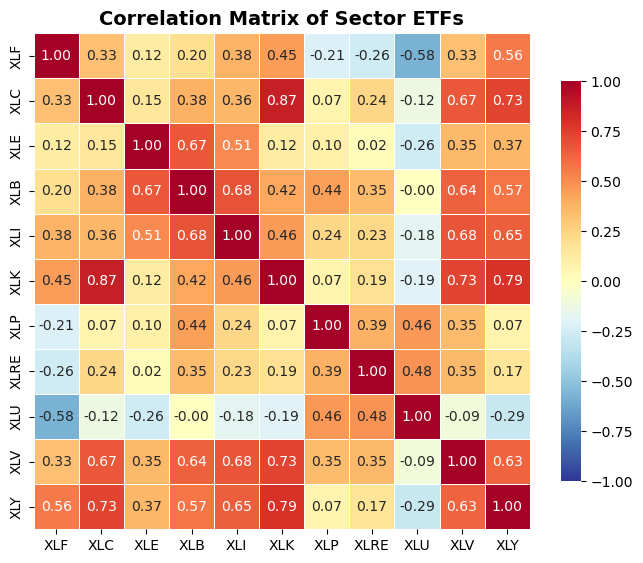

In [50]:
# Plot the first correlation matrix as a heatmap for flowchart
labels = df_logreturns.columns[1:].tolist()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(correlation_matrices[0], annot=True, fmt=".2f", cmap="RdYlBu_r", vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, xticklabels=labels, yticklabels=labels, ax=ax)
plt.title(f"Correlation Matrix of Sector ETFs", fontsize=14, fontweight="bold")
plt.show()

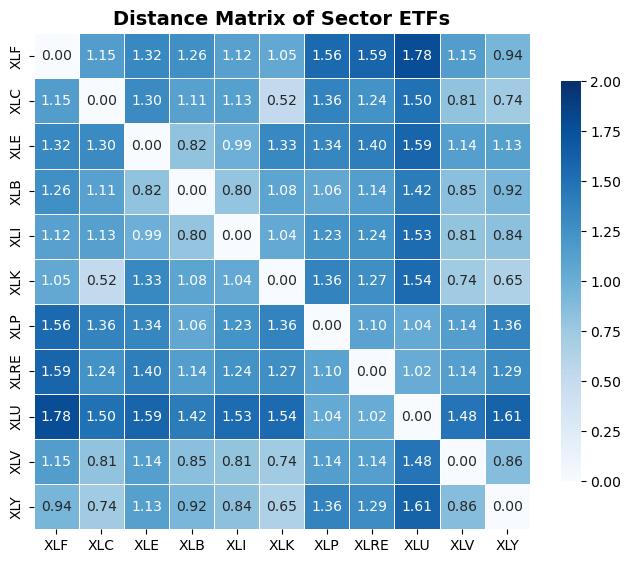

In [51]:
# Plot the first distance matrix as a heatmap for flowchart
labels = df_logreturns.columns[1:].tolist()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(distance_matrices[0], annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=2, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, xticklabels=labels, yticklabels=labels, ax=ax)
plt.title(f"Distance Matrix of Sector ETFs", fontsize=14, fontweight="bold")
plt.show()

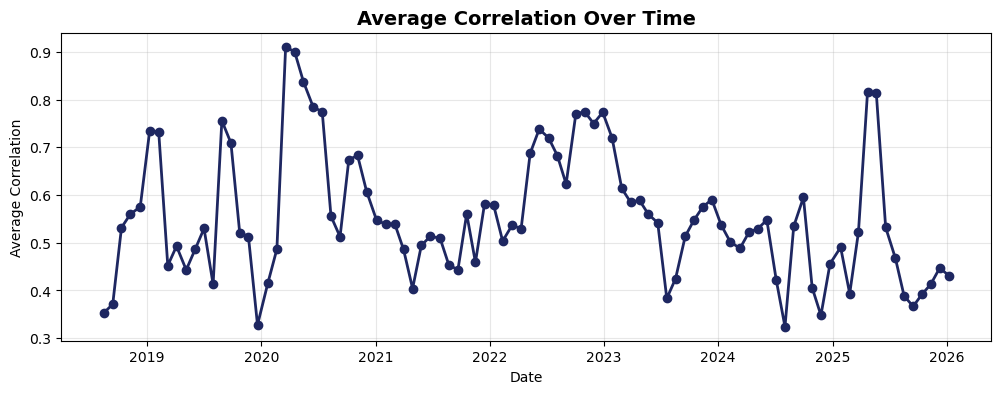

In [52]:
plt.figure(figsize=(12, 4))
plt.plot(epoch_dates, mu_values, color="#1E2761", label="Average Correlation", marker="o", linewidth=2)
plt.title("Average Correlation Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Average Correlation")
plt.grid(True, alpha=0.3)
plt.savefig("images/fig6_avg_corr_sectors2018.png", dpi=200, bbox_inches="tight")
plt.show()

In [53]:
mst_graphs = []
central_nodes = []
for D in distance_matrices:
    G = mst_graph(D, stock_names=stock_names)
    centrality = nx.betweenness_centrality(G)
    central_node = max(centrality, key=centrality.get)
    central_nodes.append(central_node)
    mst_graphs.append(G)

threshold_graphs = []
for C in correlation_matrices:
    G = threshold_graph(C, stock_names=stock_names, corr_threshold=0.75)
    threshold_graphs.append(G)

mst_threshold_graphs = []
for C, D in zip(correlation_matrices, distance_matrices):
    G = mst_threshold_graph(C, D, stock_names=stock_names, corr_threshold=0.75)
    mst_threshold_graphs.append(G)

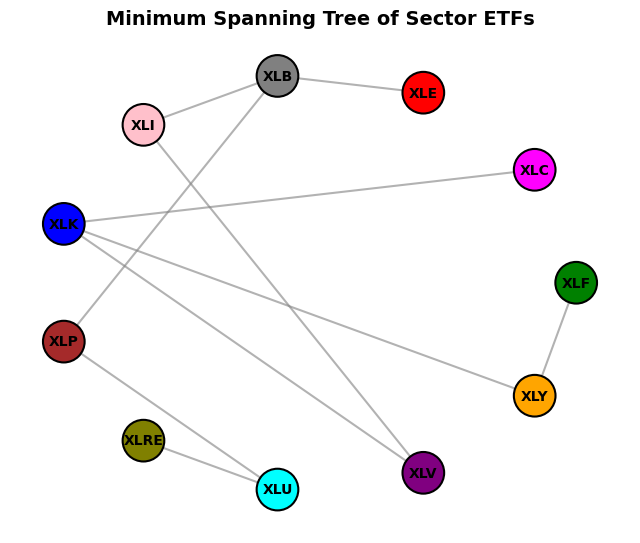

In [54]:
sector_colors = {
    "XLK": "blue",     # Tech
    "XLF": "green",    # Financials
    "XLE": "red",      # Energy
    "XLV": "purple",   # Healthcare
    "XLY": "orange",   # Consumer Discretionary
    "XLP": "brown",    # Consumer Staples
    "XLI": "pink",     # Industrials
    "XLB": "gray",     # Materials
    "XLU": "cyan",     # Utilities
    "XLC": "magenta",  # Communication Services
    "XLRE": "olive",    # Real Estate
}

# Plot the first MST graph for flowchart
pos = nx.circular_layout(mst_graphs[0])
plt.figure(figsize=(8, 6.5))
nx.draw_networkx_edges(mst_graphs[0], pos, edge_color="gray", alpha=0.6, width=1.5)
nx.draw_networkx_nodes(mst_graphs[0], pos, node_color=[sector_colors[node] for node in mst_graphs[0].nodes()], node_size=900, edgecolors="black", linewidths=1.5)
nx.draw_networkx_labels(mst_graphs[0], pos, font_size=10, font_weight="bold")
plt.title("Minimum Spanning Tree of Sector ETFs", fontsize=14, fontweight="bold")
plt.axis("off")
plt.show()

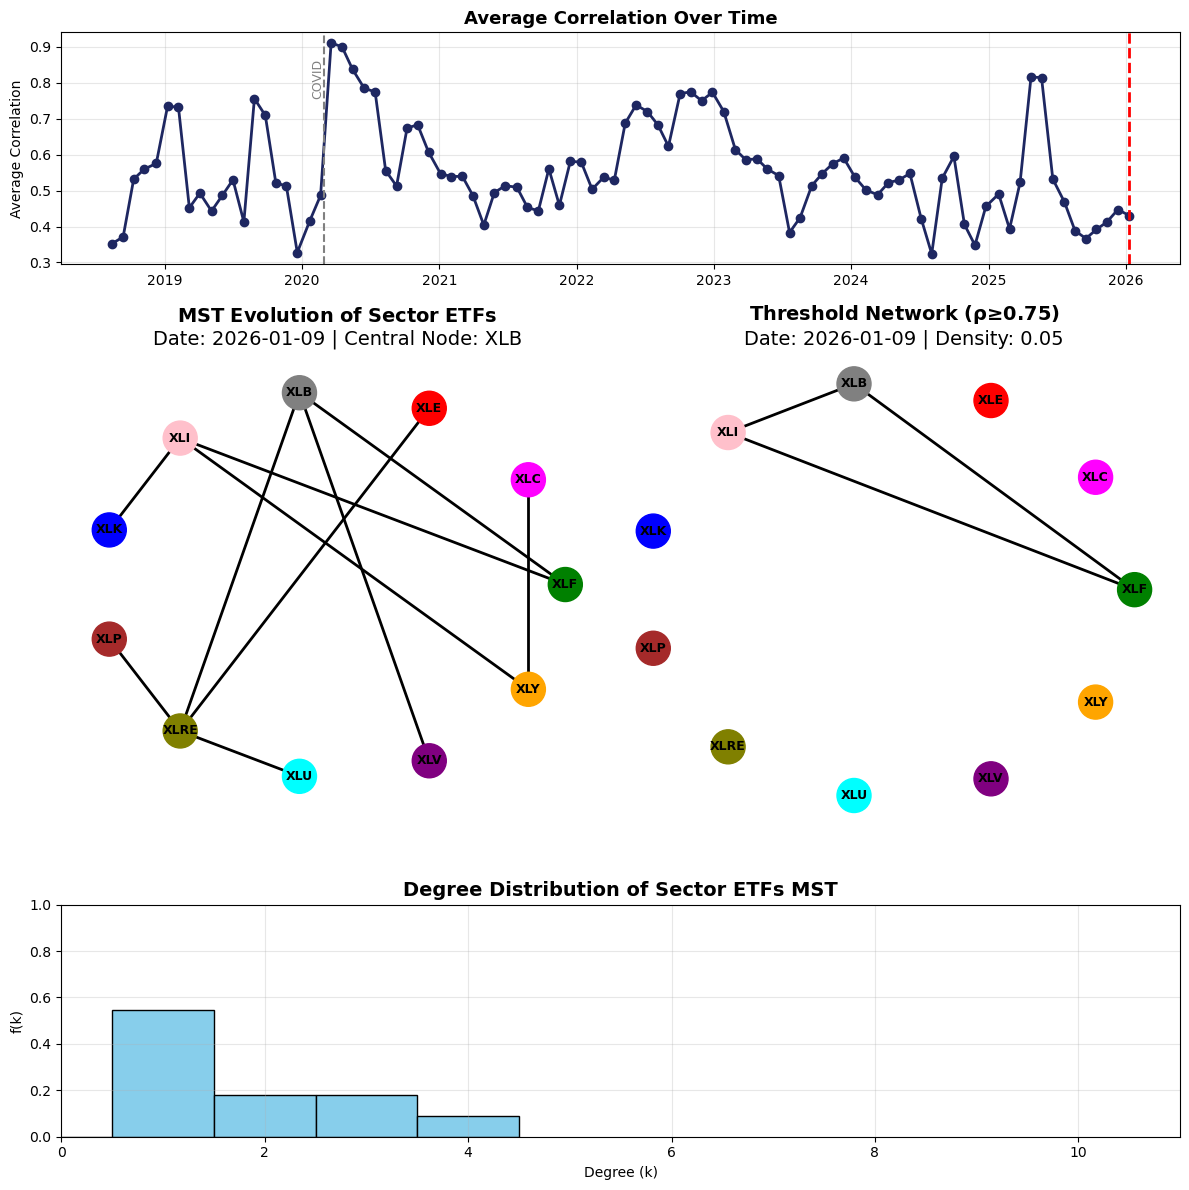

In [55]:
crisis_events = [
    ("2000-03-01", "Dot-com"),
    ("2008-09-15", "GFC"),
    ("2020-03-01", "COVID")
]
crisis_events = [(pd.to_datetime(date), label) for date, label in crisis_events]

fig = plt.figure(figsize=(12, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 2, 1])

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[2, :])

fig.subplots_adjust(hspace=0.4, wspace=0.2)

pos = nx.circular_layout(mst_graphs[0])

def update(frame):
    ax1.clear()

    ax1.plot(epoch_dates, mu_values, color="#1E2761", marker="o", linewidth=2)
    ax1.axvline(x=epoch_dates[frame], color="red", linewidth=2, linestyle="--")
    for date, label in crisis_events:
        if epoch_dates[0] <= date:
            ax1.axvline(x=date, color="gray", linestyle="--", linewidth=1.5)
            ax1.text(date, max(mu_values)*0.95, label, rotation=90, verticalalignment="top", horizontalalignment="right", fontsize=9, color="gray")
    ax1.set_title("Average Correlation Over Time", fontsize=13, fontweight="bold")
    ax1.set_ylabel("Average Correlation")
    ax1.grid(True, alpha=0.3)

    ax2.clear()

    G_mst = mst_graphs[frame]
    node_colors = [sector_colors.get(node, "lightblue") for node in G_mst.nodes()]
    nx.draw_networkx_edges(G_mst, pos, ax=ax2, edge_color="black", width=2)
    nx.draw_networkx_nodes(G_mst, pos, ax=ax2, node_color=node_colors, node_size=600)
    nx.draw_networkx_labels(G_mst, pos, ax=ax2, font_size=9, font_weight="bold")

    ax2.set_title(r"$\bf{MST\ Evolution\ of\ Sector\ ETFs}$" + "\n" + f"Date: {epoch_dates[frame].date()} | Central Node: {central_nodes[frame]}", fontsize=14)
    ax2.axis("off")

    ax3.clear()

    G_thr = threshold_graphs[frame]
    nx.draw_networkx_edges(G_thr, pos, ax=ax3, edge_color="black", width=2)
    nx.draw_networkx_nodes(G_thr, pos, ax=ax3, node_color=node_colors, node_size=600)
    nx.draw_networkx_labels(G_thr, pos, ax=ax3, font_size=9, font_weight="bold")

    ax3.set_title(r"$\bf{Threshold\ Network\ (ρ ≥ 0.75)}$" + "\n" + f"Date: {epoch_dates[frame].date()} | Density: {nx.density(G_thr):.2f}", fontsize=14)
    ax3.axis("off")

    ax4.clear()

    degrees = [d for _, d in G_mst.degree()]
    unique_k, counts = np.unique(degrees, return_counts=True)
    f_k = counts / counts.sum()

    ax4.hist(degrees, bins=np.arange(0, max(degrees) + 2) - 0.5, density=True, color="skyblue", edgecolor="black")

    ax4.set_title("Degree Distribution of Sector ETFs MST", fontsize=14, fontweight="bold")
    ax4.set_xlabel("Degree (k)")
    ax4.set_ylabel("f(k)")

    ax4.set_xlim(0, 11)
    ax4.set_ylim(0, 1)

    ax4.grid(True, alpha=0.3)


ani = animation.FuncAnimation(fig, update, frames=len(mst_graphs), interval=280, repeat=True)
ani.save("MST_evolution_sectors2018.mp4", writer="ffmpeg", dpi=300)

plt.tight_layout()
plt.show()